In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "../data/safiri_final_shipment_eta_dataset_250.csv"
)

# Convert timestamp columns
time_columns = [
    "scheduled_departure",
    "estimated_departure",
    "actual_departure",
    "scheduled_arrival",
    "estimated_arrival",
    "actual_arrival"
]

for column in time_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

# Create ETA update feature
df["eta_update_gap_hours"] = (
    df["estimated_arrival"]
    - df["scheduled_arrival"]
).dt.total_seconds() / 3600

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (250, 16)

Columns:
['ship', 'depPort', 'arrPort', 'route', 'scheduled_departure', 'estimated_departure', 'actual_departure', 'scheduled_arrival', 'estimated_arrival', 'actual_arrival', 'departure_delay_hours', 'scheduled_transit_hours', 'actual_transit_hours', 'avg_speed_knots', 'arrival_delay_hours', 'eta_update_gap_hours']


,ship,depPort,arrPort,route,scheduled_departure,estimated_departure,actual_departure,scheduled_arrival,estimated_arrival,actual_arrival,departure_delay_hours,scheduled_transit_hours,actual_transit_hours,avg_speed_knots,arrival_delay_hours,eta_update_gap_hours
0,Megastar,FIHEL,EETLL,FIHEL → EETLL,2018-04-06 07:30:00+00:00,2018-04-06 07:30:00+00:00,2018-04-06 06:30:14+00:00,2018-04-06 09:30:00+00:00,2018-04-06 09:29:00+00:00,2018-04-06 09:32:00+00:00,-0.996111,2.0,3.029444,21.163551,0.033333,-0.016667
1,Megastar,EETLL,FIHEL,EETLL → FIHEL,2018-04-06 16:30:00+00:00,2018-04-06 16:30:00+00:00,2018-04-06 15:25:21+00:00,2018-04-06 18:30:00+00:00,2018-04-06 18:23:00+00:00,2018-04-06 18:49:00+00:00,-1.077500,2.0,3.394167,19.996825,0.316667,-0.116667
2,Star,FIHEL,EETLL,FIHEL → EETLL,2018-04-06 16:30:00+00:00,2018-04-06 16:30:00+00:00,2018-04-06 16:20:14+00:00,2018-04-06 18:30:00+00:00,2018-04-06 18:26:00+00:00,2018-04-06 18:26:00+00:00,-0.162778,2.0,2.096111,20.699130,-0.066667,-0.066667
3,Star,EETLL,FIHEL,EETLL → FIHEL,2018-04-07 07:30:00+00:00,2018-04-07 07:30:00+00:00,2018-04-07 07:20:15+00:00,2018-04-07 09:30:00+00:00,2018-04-07 09:32:00+00:00,2018-04-07 09:51:00+00:00,-0.162500,2.0,2.512500,20.196850,0.350000,0.033333
4,Megastar,EETLL,FIHEL,EETLL → FIHEL,2018-04-07 10:30:00+00:00,2018-04-07 10:30:00+00:00,2018-04-07 10:19:14+00:00,2018-04-07 12:30:00+00:00,2018-04-07 12:31:00+00:00,2018-04-07 13:09:00+00:00,-0.179444,2.0,2.829444,20.320769,0.650000,0.016667


In [112]:
print("Number of shipments:", len(df))

print("\nArrival delay statistics:")
print(
    df["arrival_delay_hours"].describe()
)

Number of shipments: 250

Arrival delay statistics:
count    250.000000
mean       0.275667
std        0.241232
min       -0.400000
25%        0.083333
50%        0.283333
75%        0.466667
max        1.066667
Name: arrival_delay_hours, dtype: float64


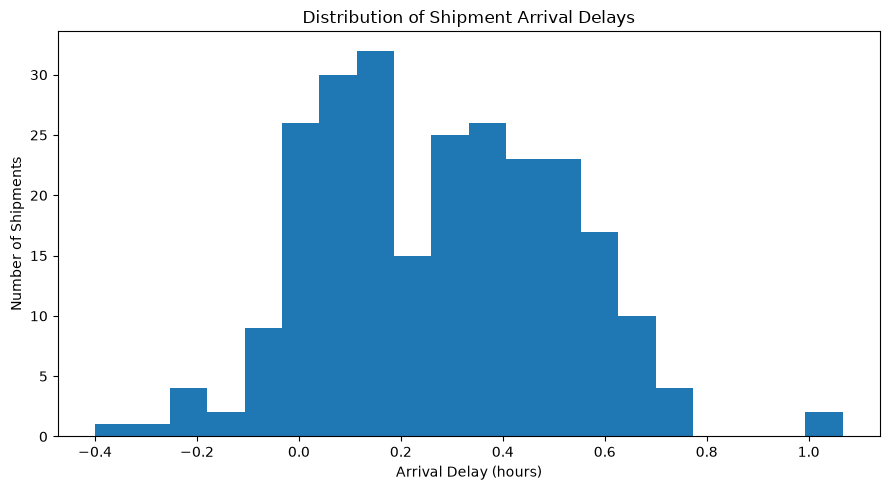

In [113]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["arrival_delay_hours"],
    bins=20
)

plt.xlabel("Arrival Delay (hours)")
plt.ylabel("Number of Shipments")
plt.title("Distribution of Shipment Arrival Delays")

plt.tight_layout()
plt.show()

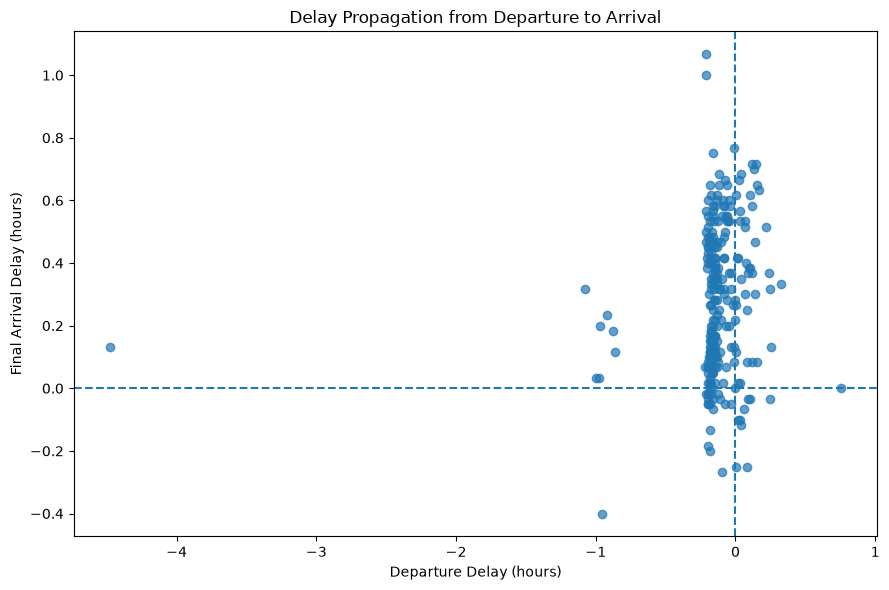

In [114]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["departure_delay_hours"],
    df["arrival_delay_hours"],
    alpha=0.7
)

plt.xlabel("Departure Delay (hours)")
plt.ylabel("Final Arrival Delay (hours)")

plt.title(
    "Delay Propagation from Departure to Arrival"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [115]:
correlation = df[
    [
        "departure_delay_hours",
        "arrival_delay_hours"
    ]
].corr().iloc[0, 1]

print(
    f"Departure → Arrival delay correlation: "
    f"{correlation:.3f}"
)

Departure → Arrival delay correlation: 0.118


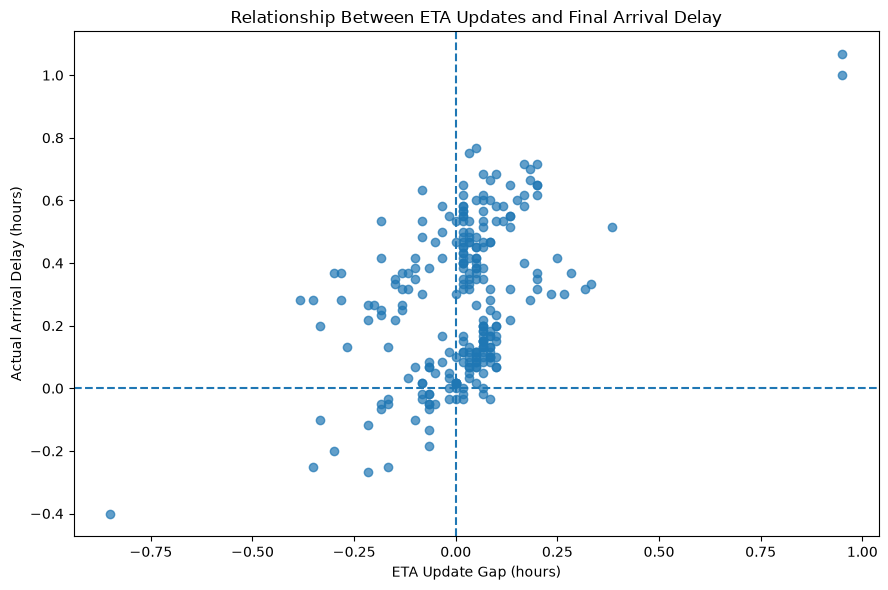

In [116]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["eta_update_gap_hours"],
    df["arrival_delay_hours"],
    alpha=0.7
)

plt.xlabel(
    "ETA Update Gap (hours)"
)

plt.ylabel(
    "Actual Arrival Delay (hours)"
)

plt.title(
    "Relationship Between ETA Updates and Final Arrival Delay"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.tight_layout()
plt.show()



In [117]:
eta_correlation = df[
    [
        "eta_update_gap_hours",
        "arrival_delay_hours"
    ]
].corr().iloc[0, 1]

print(
    f"ETA update → Arrival delay correlation: "
    f"{eta_correlation:.3f}"
)

ETA update → Arrival delay correlation: 0.466


In [118]:
# Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Load feature importance generated by the model
importance_df = pd.read_csv("../data/feature_importance.csv")

# Display top features
top_features = importance_df.sort_values(
    "importance", ascending=False
).head(15)

print("Top 15 Important Features:")
display(top_features)

Top 15 Important Features:


,feature,importance
0,numeric__eta_update_gap_hours,0.276404
1,categorical__arrPort_FIHEL,0.132476
2,categorical__route_EETLL → FIHEL,0.114105
3,categorical__depPort_EETLL,0.109651
4,numeric__departure_delay_hours,0.100235
5,categorical__depPort_FIHEL,0.081571
6,categorical__route_FIHEL → EETLL,0.064608
7,categorical__arrPort_EETLL,0.062664
8,numeric__scheduled_departure_dayofweek,0.021539
9,numeric__scheduled_departure_hour,0.016035


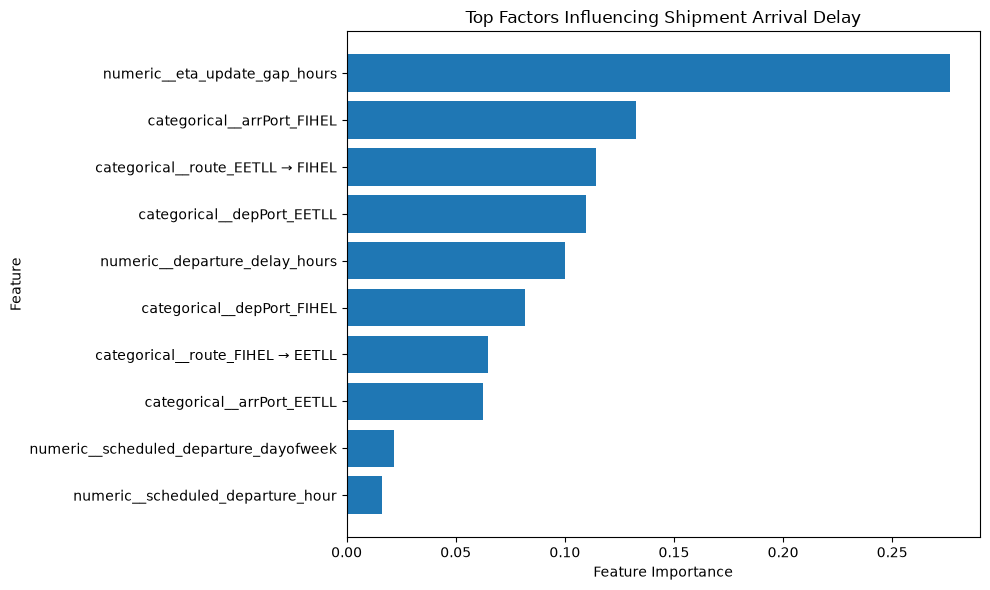

In [119]:
# Plot top 10 feature importances

top_10 = importance_df.sort_values(
    "importance", ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["feature"][::-1],
    top_10["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Shipment Arrival Delay")

plt.tight_layout()
plt.show()

In [120]:
# Group feature importance into meaningful categories

importance_df["feature_group"] = importance_df["feature"].apply(
    lambda x:
        "ETA Update" if "eta_update_gap" in x
        else "Departure Delay" if "departure_delay" in x
        else "Route" if "route" in x
        else "Arrival Port" if "arrPort" in x
        else "Departure Port" if "depPort" in x
        else "Scheduled Time" if "scheduled" in x
        else "Ship" if "ship" in x
        else "Other"
)

grouped_importance = (
    importance_df
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("Grouped Feature Importance:")
display(grouped_importance)

Grouped Feature Importance:


feature_group
ETA Update         0.276404
Arrival Port       0.195139
Departure Port     0.191222
Route              0.178714
Departure Delay    0.100235
Scheduled Time     0.048011
Ship               0.010274
Name: importance, dtype: float64

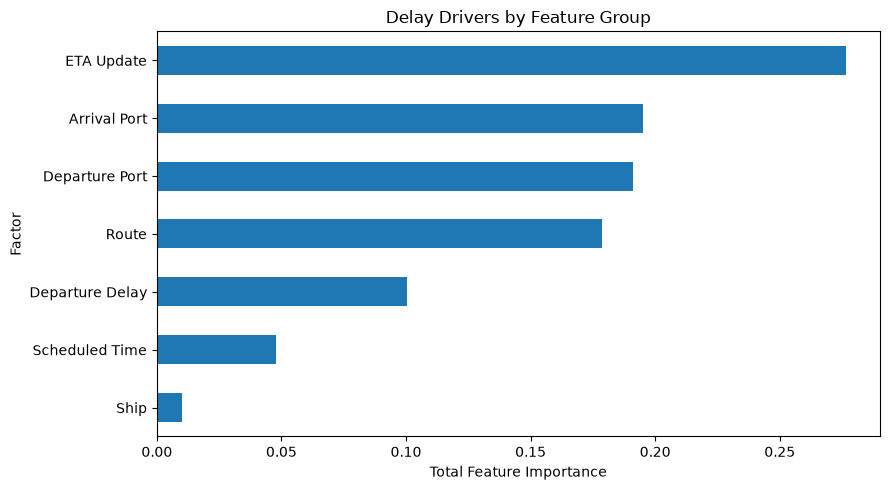

In [121]:
plt.figure(figsize=(9, 5))

grouped_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Total Feature Importance")
plt.ylabel("Factor")
plt.title("Delay Drivers by Feature Group")

plt.tight_layout()
plt.show()

In [122]:
# Average arrival delay by route

route_analysis = (
    df.groupby("route")["arrival_delay_hours"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Arrival Delay by Route:")
display(route_analysis)

Arrival Delay by Route:


,count,mean,median,min,max
route,,,,,
EETLL → FIHEL,129,0.445090,0.45,-0.400000,1.066667
FIHEL → EETLL,121,0.095041,0.10,-0.266667,0.516667


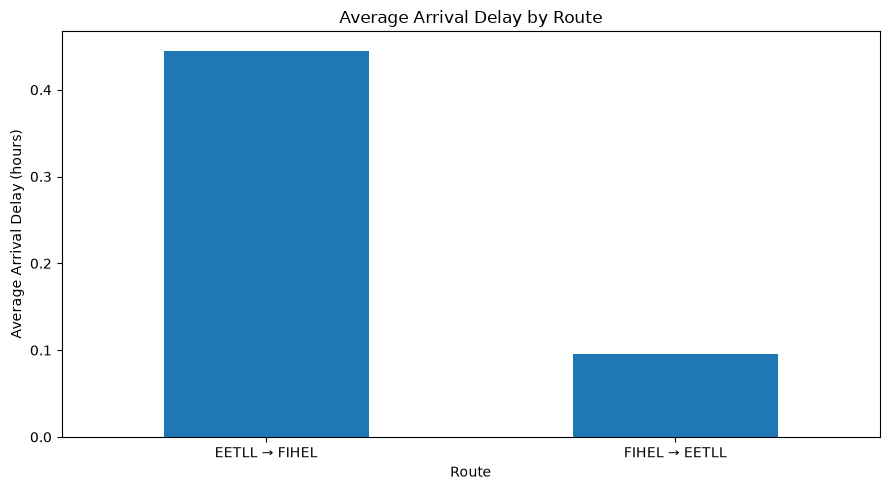

In [123]:
plt.figure(figsize=(9, 5))

route_analysis["mean"].plot(kind="bar")

plt.xlabel("Route")
plt.ylabel("Average Arrival Delay (hours)")
plt.title("Average Arrival Delay by Route")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [124]:
# Average arrival delay by destination port

port_analysis = (
    df.groupby("arrPort")["arrival_delay_hours"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Arrival Delay by Destination Port:")
display(port_analysis)

Arrival Delay by Destination Port:


,count,mean,median,min,max
arrPort,,,,,
FIHEL,129,0.445090,0.45,-0.400000,1.066667
EETLL,121,0.095041,0.10,-0.266667,0.516667


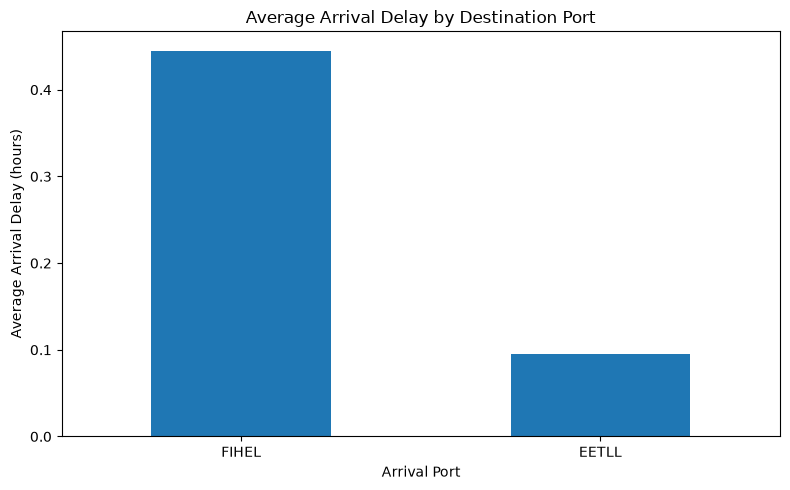

In [125]:
plt.figure(figsize=(8, 5))

port_analysis["mean"].plot(kind="bar")

plt.xlabel("Arrival Port")
plt.ylabel("Average Arrival Delay (hours)")
plt.title("Average Arrival Delay by Destination Port")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [126]:
# Average arrival delay by departure port

departure_port_analysis = (
    df.groupby("depPort")["arrival_delay_hours"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Arrival Delay by Departure Port:")
display(departure_port_analysis)

Arrival Delay by Departure Port:


,count,mean,median,min,max
depPort,,,,,
EETLL,129,0.445090,0.45,-0.400000,1.066667
FIHEL,121,0.095041,0.10,-0.266667,0.516667


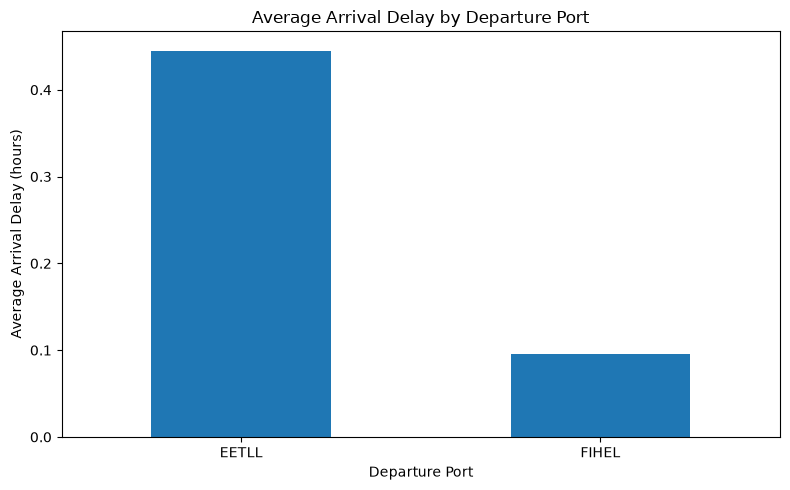

In [127]:
plt.figure(figsize=(8, 5))

departure_port_analysis["mean"].plot(kind="bar")

plt.xlabel("Departure Port")
plt.ylabel("Average Arrival Delay (hours)")
plt.title("Average Arrival Delay by Departure Port")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [128]:
# Compare departure delay and final arrival delay

propagation = df[
    ["departure_delay_hours", "arrival_delay_hours"]
].describe()

display(propagation)

,departure_delay_hours,arrival_delay_hours
count,250.000000,250.000000
mean,-0.138474,0.275667
std,0.337576,0.241232
min,-4.475556,-0.400000
25%,-0.179444,0.083333
50%,-0.147222,0.283333
75%,-0.046667,0.466667
max,0.753611,1.066667


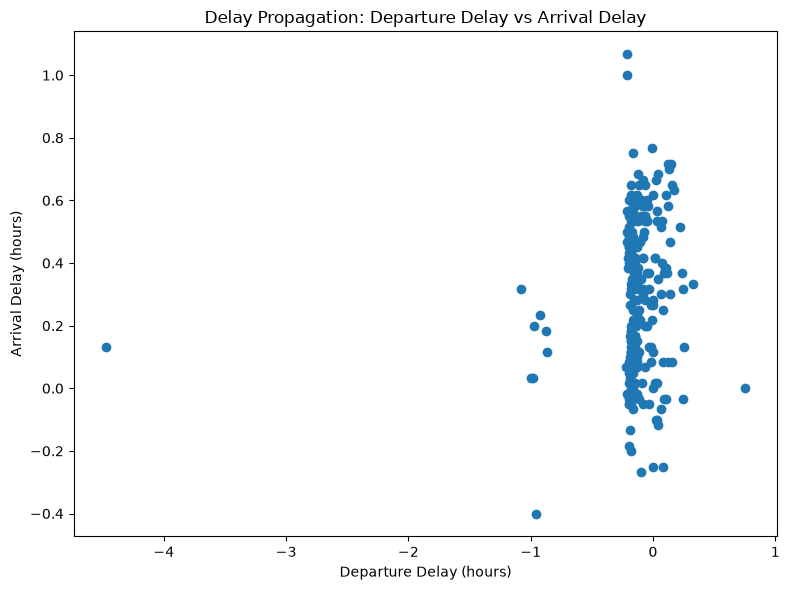

In [129]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["departure_delay_hours"],
    df["arrival_delay_hours"]
)

plt.xlabel("Departure Delay (hours)")
plt.ylabel("Arrival Delay (hours)")
plt.title("Delay Propagation: Departure Delay vs Arrival Delay")

plt.tight_layout()
plt.show()

In [130]:
# Measure whether the delay increased during the voyage

df["delay_propagation"] = (
    df["arrival_delay_hours"] - df["departure_delay_hours"]
)

increased = (df["delay_propagation"] > 0).sum()
reduced = (df["delay_propagation"] < 0).sum()
unchanged = (df["delay_propagation"] == 0).sum()

total = len(df)

print(f"Delay increased: {increased} ({increased/total*100:.1f}%)")
print(f"Delay reduced: {reduced} ({reduced/total*100:.1f}%)")
print(f"Delay unchanged: {unchanged} ({unchanged/total*100:.1f}%)")

Delay increased: 231 (92.4%)
Delay reduced: 19 (7.6%)
Delay unchanged: 0 (0.0%)


In [131]:
# 7. Actual Shipment Delay Prediction

import joblib
import pandas as pd

# Load the trained model
model = joblib.load("../data/eta_prediction_model.pkl")

# Select one shipment from the test/prediction data
sample = df.iloc[[0]].copy()

print("Shipment details:")
display(
    sample[
        [
            "ship",
            "depPort",
            "arrPort",
            "route",
            "departure_delay_hours",
            "scheduled_transit_hours",
            "eta_update_gap_hours"
        ]
    ]
)

Shipment details:


,ship,depPort,arrPort,route,departure_delay_hours,scheduled_transit_hours,eta_update_gap_hours
0,Megastar,FIHEL,EETLL,FIHEL → EETLL,-0.996111,2.0,-0.016667


In [132]:
# Create the time-based features used during model training

df["scheduled_departure_hour"] = (
    df["scheduled_departure"].dt.hour
)

df["scheduled_departure_dayofweek"] = (
    df["scheduled_departure"].dt.dayofweek
)

print("Time-based features created successfully.")

display(
    df[
        [
            "scheduled_departure",
            "scheduled_departure_hour",
            "scheduled_departure_dayofweek"
        ]
    ].head()
)

Time-based features created successfully.


,scheduled_departure,scheduled_departure_hour,scheduled_departure_dayofweek
0,2018-04-06 07:30:00+00:00,7,4
1,2018-04-06 16:30:00+00:00,16,4
2,2018-04-06 16:30:00+00:00,16,4
3,2018-04-07 07:30:00+00:00,7,5
4,2018-04-07 10:30:00+00:00,10,5


In [133]:
# Recreate sample after adding the new features

sample = df.iloc[[0]].copy()

In [134]:
# Features used by the model

features = [
    "departure_delay_hours",
    "scheduled_transit_hours",
    "eta_update_gap_hours",
    "scheduled_departure_hour",
    "scheduled_departure_dayofweek",
    "ship",
    "depPort",
    "arrPort",
    "route"
]

X_sample = sample[features]

predicted_delay = model.predict(X_sample)[0]

actual_delay = sample["arrival_delay_hours"].iloc[0]

print(f"Predicted arrival delay: {predicted_delay:.2f} hours")
print(f"Actual arrival delay:    {actual_delay:.2f} hours")
print(f"Prediction error:        {abs(predicted_delay - actual_delay):.2f} hours")

Predicted arrival delay: 0.01 hours
Actual arrival delay:    0.03 hours
Prediction error:        0.02 hours


In [135]:
predicted_minutes = predicted_delay * 60
actual_minutes = actual_delay * 60

print(f"Predicted delay: {predicted_minutes:.1f} minutes")
print(f"Actual delay:    {actual_minutes:.1f} minutes")

Predicted delay: 0.7 minutes
Actual delay:    2.0 minutes


In [136]:
# Human-readable explanation

print("\n--- Shipment Delay Explanation ---")

print(
    f"Route: {sample['route'].iloc[0]}"
)

print(
    f"Departure delay: "
    f"{sample['departure_delay_hours'].iloc[0]:.2f} hours"
)

print(
    f"ETA update gap: "
    f"{sample['eta_update_gap_hours'].iloc[0]:.2f} hours"
)

print(
    f"Scheduled transit time: "
    f"{sample['scheduled_transit_hours'].iloc[0]:.2f} hours"
)

print(
    f"Predicted final arrival delay: "
    f"{predicted_delay:.2f} hours"
)


--- Shipment Delay Explanation ---
Route: FIHEL → EETLL
Departure delay: -1.00 hours
ETA update gap: -0.02 hours
Scheduled transit time: 2.00 hours
Predicted final arrival delay: 0.01 hours


In [137]:
# 8. Model Performance Summary

performance = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Baseline (Departure Delay)"
    ],
    "MAE (hours)": [
        0.0733,
        0.4391
    ],
    "RMSE (hours)": [
        0.1019,
        0.5082
    ],
    "R²": [
        0.8124,
        None
    ]
})

display(performance)

,Model,MAE (hours),RMSE (hours),R²
0,Random Forest,0.0733,0.1019,0.8124
1,Baseline (Departure Delay),0.4391,0.5082,NaN


In [138]:
baseline_mae = 0.4391
model_mae = 0.0733

improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
) * 100

print(
    f"MAE improvement over baseline: "
    f"{improvement:.1f}%"
)

MAE improvement over baseline: 83.3%


In [139]:
# 9. Final Model Summary

print("=" * 50)
print("SAFIRI AI - SHIPMENT ETA PREDICTION")
print("=" * 50)

print("\nModel: Random Forest Regressor")

print("\nPerformance:")
print("MAE  : 0.0733 hours (~4.4 minutes)")
print("RMSE : 0.1019 hours (~6.1 minutes)")
print("R²   : 0.8124")

print("\nBaseline:")
print("MAE  : 0.4391 hours (~26.3 minutes)")
print("RMSE : 0.5082 hours")

print("\nImprovement:")
print("MAE improvement over baseline: 83.3%")

print("\nPrediction Example:")
print(f"Predicted delay: {predicted_delay:.2f} hours")
print(f"Actual delay:    {actual_delay:.2f} hours")
print(
    f"Prediction error: "
    f"{abs(predicted_delay - actual_delay):.2f} hours"
)

print("\nTop Delay Factors:")
display(grouped_importance)

SAFIRI AI - SHIPMENT ETA PREDICTION

Model: Random Forest Regressor

Performance:
MAE  : 0.0733 hours (~4.4 minutes)
RMSE : 0.1019 hours (~6.1 minutes)
R²   : 0.8124

Baseline:
MAE  : 0.4391 hours (~26.3 minutes)
RMSE : 0.5082 hours

Improvement:
MAE improvement over baseline: 83.3%

Prediction Example:
Predicted delay: 0.01 hours
Actual delay:    0.03 hours
Prediction error: 0.02 hours

Top Delay Factors:


feature_group
ETA Update         0.276404
Arrival Port       0.195139
Departure Port     0.191222
Route              0.178714
Departure Delay    0.100235
Scheduled Time     0.048011
Ship               0.010274
Name: importance, dtype: float64

<StringArray>
['Megastar', 'Star', 'Finlandia', 'Europa']
Length: 4, dtype: str
<StringArray>
['FIHEL', 'EETLL']
Length: 2, dtype: str
<StringArray>
['EETLL', 'FIHEL']
Length: 2, dtype: str
<StringArray>
['FIHEL → EETLL', 'EETLL → FIHEL']
Length: 2, dtype: str
